# Fotones gamma de captura: figuras de la Sección 4.2 de la tesis (Campaña 1)

Este notebook regenera las figuras de los fotones gamma producidos tras la captura de los neutrones (Campaña 1:
16 energías × 4 medios, $10^5$ neutrones por corrida, `QGSP_BERT_HP` sin $S(\alpha,\beta)$). Solo lee los resúmenes
que produce `procesar_gammas.py` (`resultados_gammas/`).

| Figura de la tesis | Contenido | Definición |
|---|---|---|
| 4.30 | Pasos por proceso en el tanque, 5 energías | tanque estricto ($z\le1330$ mm) |
| 4.31 | Pasos `Transportation` frente a $E_n$ | tanque estricto |
| 4.32 | Pasos por proceso frente a $E_n$ | tanque estricto |
| 4.33, 4.34 | Energía de los pasos de los fotones en el tanque (agua pura y 2.5 % NaCl) | tanque ($z\le1330.05$ mm) |
| 4.35 | Dispersiones Compton frente a $E_n$ | tanque estricto |
| 4.36 y tabla de FWHM | Espectro de energía tras la dispersión Compton | tanque estricto; 1000 intervalos en [0, 2.7] MeV |
| 4.37 | Dispersiones Rayleigh frente a $E_n$ | tanque estricto |
| 4.39 | Espectro de energía de los fotones dispersados por Rayleigh | tanque; intervalos de 3 keV |
| 4.40 | Fotoabsorciones frente a $E_n$ | `phot` precedido de `compt` en el tanque estricto |
| 4.41 | Energía de los fotones antes de la fotoabsorción | ídem; 500 intervalos en [0, 0.15] MeV |
| 4.42 | Energía media antes de la fotoabsorción | ídem; media y desviación en [0.01, 0.1] MeV |

Figuras nuevas (no están en la tesis): espectro exacto de emisión y energía de las cascadas de captura (1–10 meV),
destino de los fotones y rendimientos por captura.

**Correcciones.** Las Figs. 4.31, 4.32, 4.35, 4.37 y 4.40 de la tesis se dibujaron con valores transcritos a mano;
aquí se leen de los resúmenes, lo que corrige los puntos mal copiados (por ejemplo, 7 meV con 2.5 % de NaCl).

In [1]:
import csv
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

RES = Path("resultados_gammas")
SALIDA = Path("figuras-gammas")
SALIDA.mkdir(exist_ok=True)

ENERGIAS = ["1meV", "2.5meV", "5meV", "7meV", "10meV", "25meV", "50meV", "80meV", "100meV",
            "300meV", "500meV", "700meV", "1000meV", "10000meV", "100000meV", "1000000meV"]
VALOR_MEV = np.array([1, 2.5, 5, 7, 10, 25, 50, 80, 100, 300, 500, 700, 1e3, 1e4, 1e5, 1e6])
ROTULO = dict(zip(ENERGIAS, ["1 meV", "2.5 meV", "5 meV", "7 meV", "10 meV", "25 meV", "50 meV", "80 meV",
                             "100 meV", "300 meV", "500 meV", "700 meV", "1 eV", "10 eV", "100 eV", "1 keV"]))
E5 = ["1meV", "10meV", "100meV", "1000meV", "1000000meV"]
E7 = ["1meV", "10meV", "100meV", "1000meV", "10000meV", "100000meV", "1000000meV"]
COLOR_E = dict(zip(E7, ["red", "green", "purple", "darkorange", "blue", "brown", "gray"]))
MEDIOS = ["Agua-pura", "Agua+2.5NaCl", "Agua+5NaCl", "Agua+10NaCl"]
NOMBRE = dict(zip(MEDIOS, ["Agua pura", "Agua + 2.5 % NaCl", "Agua + 5 % NaCl", "Agua + 10 % NaCl"]))
COLOR = dict(zip(MEDIOS, ["red", "green", "purple", "darkorange"]))
MARCA = dict(zip(MEDIOS, ["o", "s", "^", "D"]))
ESTILO = dict(zip(MEDIOS, ["-", "--", "-.", ":"]))

plt.rcParams.update({"font.family": "serif", "font.size": 14, "axes.labelsize": 17,
                     "legend.fontsize": 12, "axes.linewidth": 1.1})

R = {(e, m): json.loads((RES / e / m / "resumen_gammas.json").read_text()) for e in ENERGIAS for m in MEDIOS}
with open("../campana-1_neutrones-monoenergeticos_seccion-4.2/resultados/resumen_campana.tsv") as f:
    CAP = {(r["energia"], r["medio"]): int(r["capturas"]) for r in csv.DictReader(f, delimiter="\t")}


def guardar(fig, nombre):
    fig.savefig(SALIDA / f"{nombre}.pdf", bbox_inches="tight")
    fig.savefig(SALIDA / f"{nombre}.png", dpi=200, bbox_inches="tight")
    plt.show()


def regiones(ax, y_texto=None):
    for x in (10, 100, 1000):
        ax.axvline(x, color="0.35", ls="--", lw=1.2)
    if y_texto is not None:
        for x, t in [(3, "Fríos"), (30, "Térmicos"), (300, "Epitérmicos"), (3e4, "Intermedios")]:
            ax.text(x, y_texto, t, ha="center", va="bottom", fontsize=13, fontweight="bold",
                    transform=ax.get_xaxis_transform())


def eje_energia(ax):
    ax.set_xscale("log")
    ax.set_xlabel(r"Energía inicial del neutrón, $E_n$ [meV]")


def conteo(e, m, proc, zona="tanque_estricto"):
    return R[(e, m)]["procesos"][proc][zona]


def centros(h):
    return (np.arange(len(h["conteos"])) + 0.5) * h["ancho"]

## Fig. 4.30: pasos por proceso en el tanque

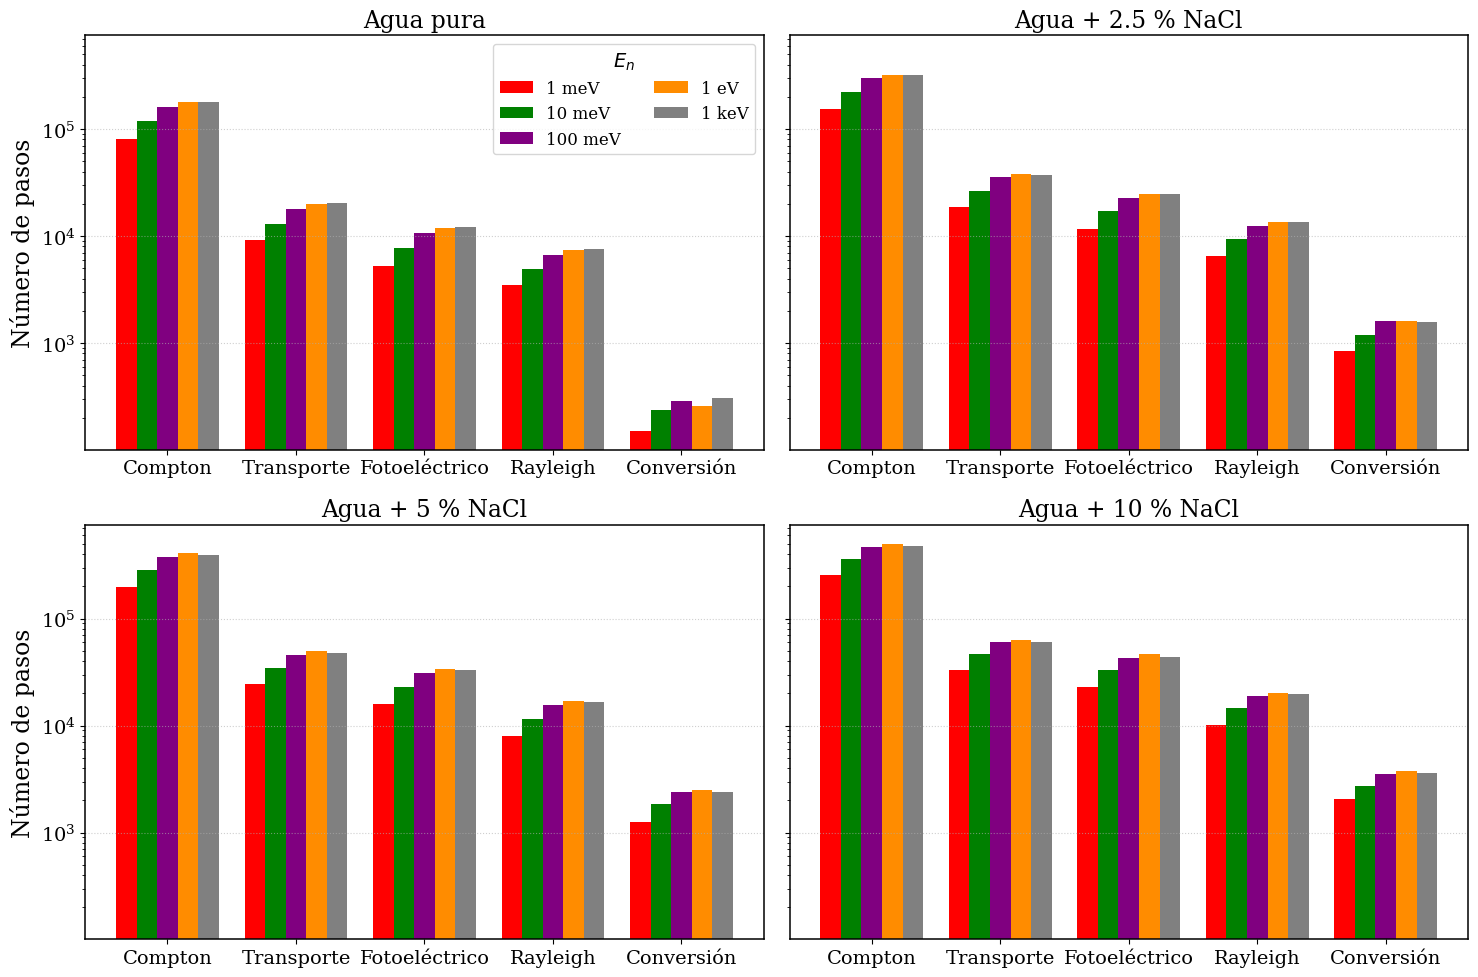

In [2]:
PROC = [("compt", "Compton"), ("Transportation", "Transporte"), ("phot", "Fotoeléctrico"), ("Rayl", "Rayleigh"),
        ("conv", "Conversión")]
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
ancho = 0.16
for ax, m in zip(axs.flat, MEDIOS):
    x = np.arange(len(PROC))
    for k, e in enumerate(E5):
        v = [conteo(e, m, p) for p, _ in PROC]
        ax.bar(x + (k - 2) * ancho, v, ancho, color=COLOR_E[e], label=ROTULO[e])
    ax.set_xticks(x, [n for _, n in PROC])
    ax.set_yscale("log")
    ax.set_title(NOMBRE[m])
    ax.grid(axis="y", ls=":", alpha=0.6)
axs[0, 0].set_ylabel("Número de pasos")
axs[1, 0].set_ylabel("Número de pasos")
axs[0, 0].legend(title=r"$E_n$", ncol=2)
fig.tight_layout()
guardar(fig, "fig_4_30_procesos_tanque")

## Figs. 4.31, 4.35, 4.37 y 4.40: conteos frente a la energía del neutrón

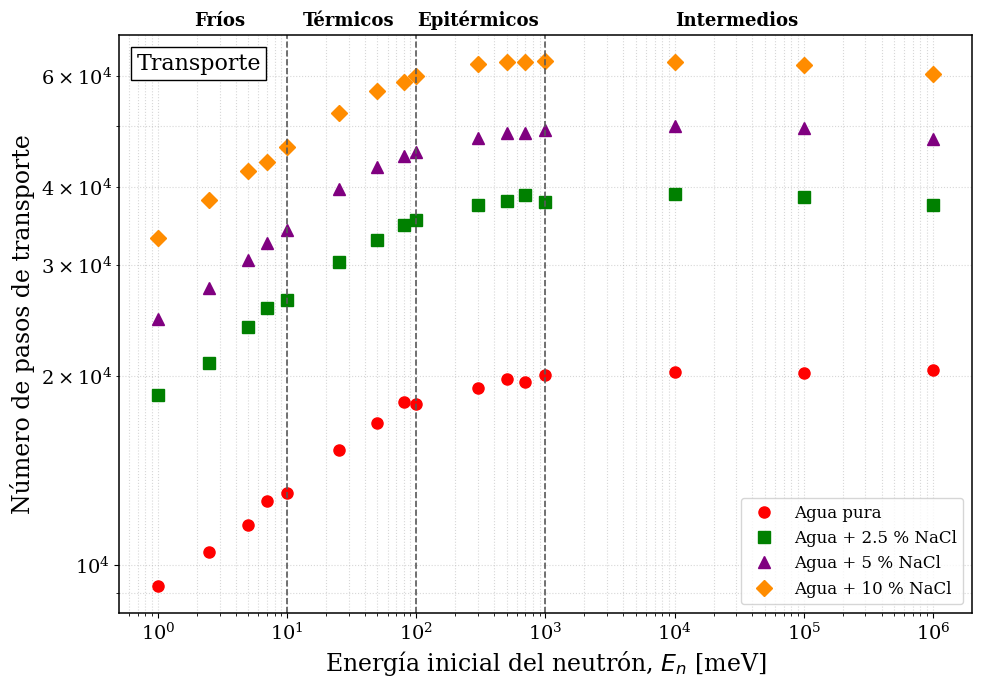

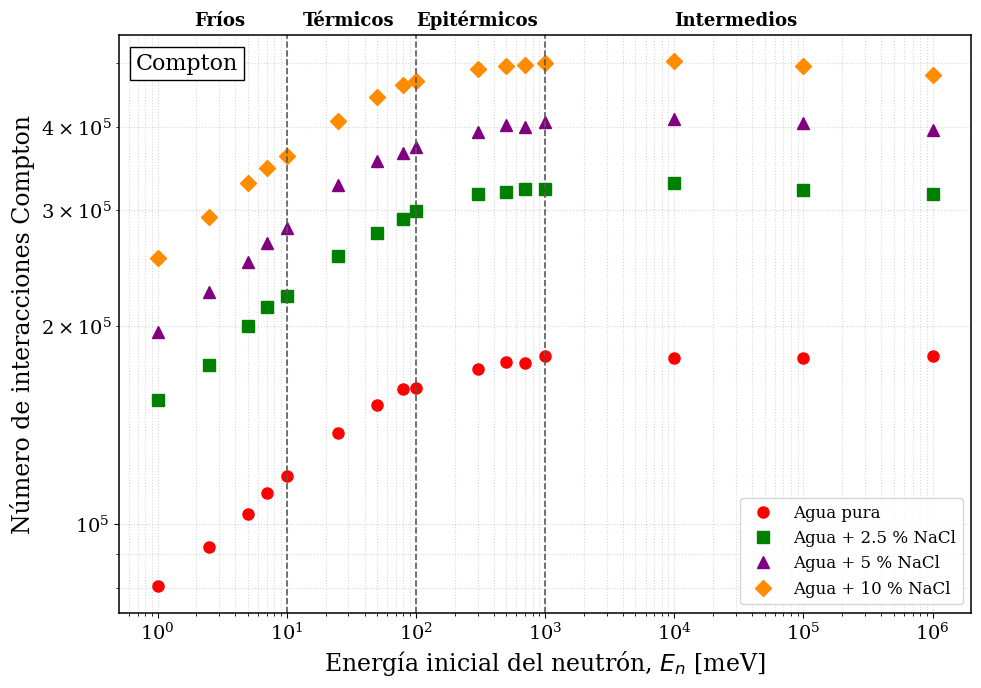

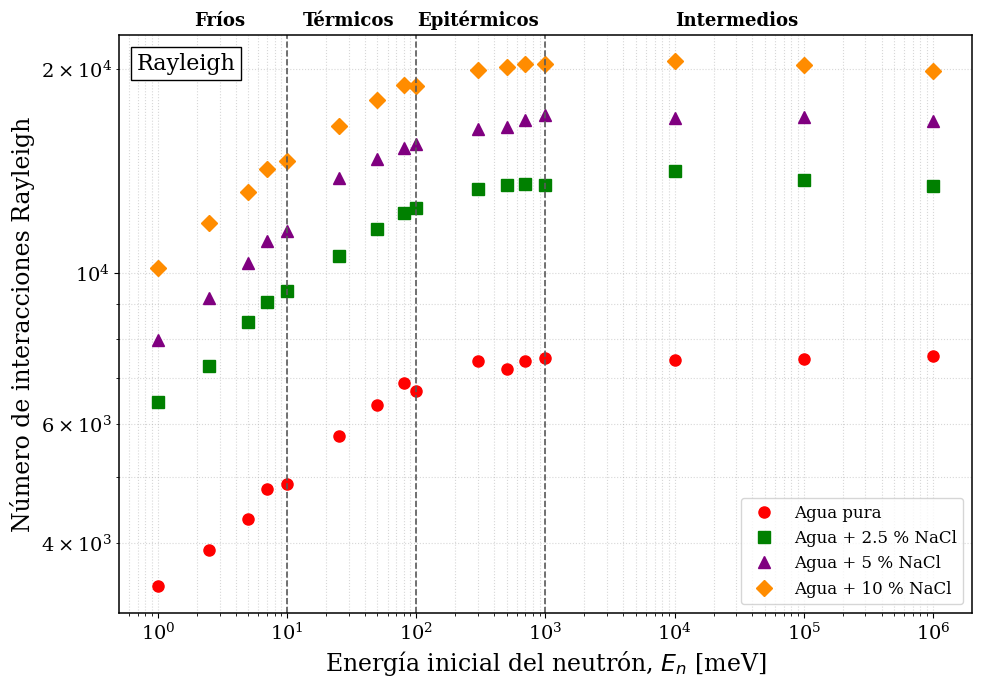

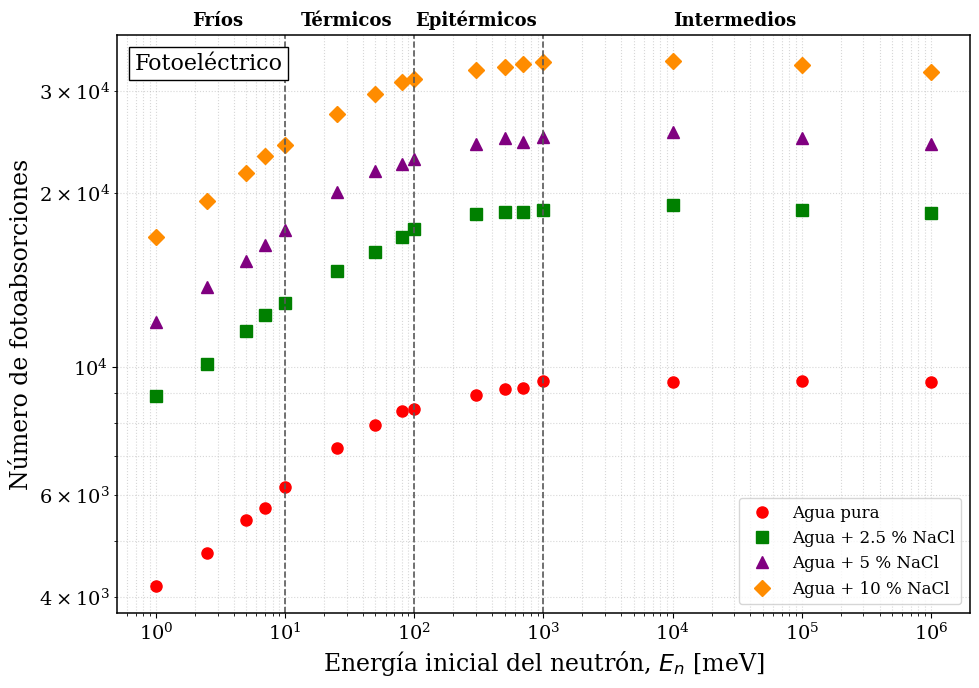

In [3]:
def vs_energia(valores, ylabel, nombre, etiqueta):
    fig, ax = plt.subplots(figsize=(11, 7.5))
    for m in MEDIOS:
        ax.plot(VALOR_MEV, valores(m), MARCA[m], color=COLOR[m], ms=8, label=NOMBRE[m])
    eje_energia(ax)
    ax.set_yscale("log")
    ax.set_ylabel(ylabel)
    regiones(ax, 1.01)
    ax.text(0.02, 0.97, etiqueta, transform=ax.transAxes, va="top", fontsize=16,
            bbox=dict(facecolor="white", edgecolor="black"))
    ax.legend(loc="lower right")
    ax.grid(True, which="both", ls=":", alpha=0.5)
    guardar(fig, nombre)


vs_energia(lambda m: [conteo(e, m, "Transportation") for e in ENERGIAS], "Número de pasos de transporte",
           "fig_4_31_transporte_vs_energia", "Transporte")
vs_energia(lambda m: [conteo(e, m, "compt") for e in ENERGIAS], "Número de interacciones Compton",
           "fig_4_35_compton_vs_energia", "Compton")
vs_energia(lambda m: [conteo(e, m, "Rayl") for e in ENERGIAS], "Número de interacciones Rayleigh",
           "fig_4_37_rayleigh_vs_energia", "Rayleigh")
vs_energia(lambda m: [R[(e, m)]["tesis_fotoabsorcion_previa_compt"]["n"] for e in ENERGIAS],
           "Número de fotoabsorciones", "fig_4_40_fotoelectrico_vs_energia", "Fotoeléctrico")

## Fig. 4.32: todos los procesos frente a la energía

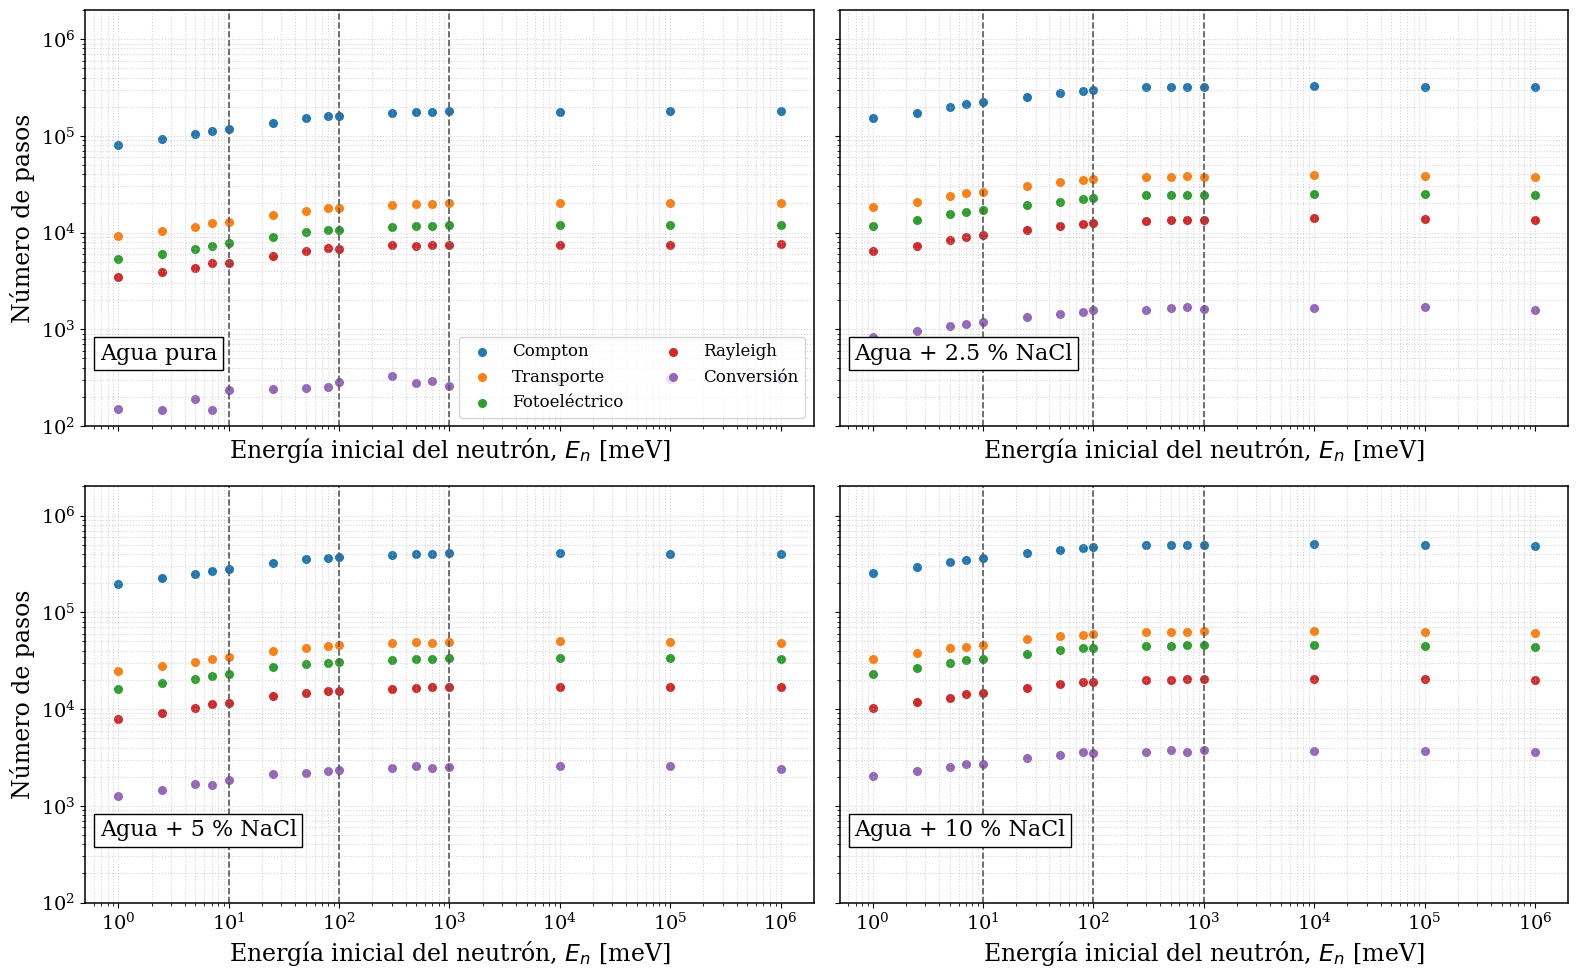

In [4]:
COLP = {"compt": "tab:blue", "Transportation": "tab:orange", "phot": "tab:green", "Rayl": "tab:red", "conv": "tab:purple"}
fig, axs = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
for ax, m in zip(axs.flat, MEDIOS):
    for p, n in PROC:
        ax.scatter(VALOR_MEV, [conteo(e, m, p) for e in ENERGIAS], color=COLP[p], s=30, label=n)
    eje_energia(ax)
    ax.set_yscale("log")
    ax.set_ylim(100, 2e6)
    regiones(ax)
    ax.text(0.02, 0.2, NOMBRE[m], transform=ax.transAxes, fontsize=16, va="top",
            bbox=dict(facecolor="white", edgecolor="black"))
    ax.grid(True, which="both", ls=":", alpha=0.5)
axs[0, 0].legend(loc="lower right", ncol=2)
for ax in axs[:, 0]:
    ax.set_ylabel("Número de pasos")
fig.tight_layout()
guardar(fig, "fig_4_32_procesos_vs_energia")

## Figs. 4.33 y 4.34: energía de los pasos de los fotones en el tanque

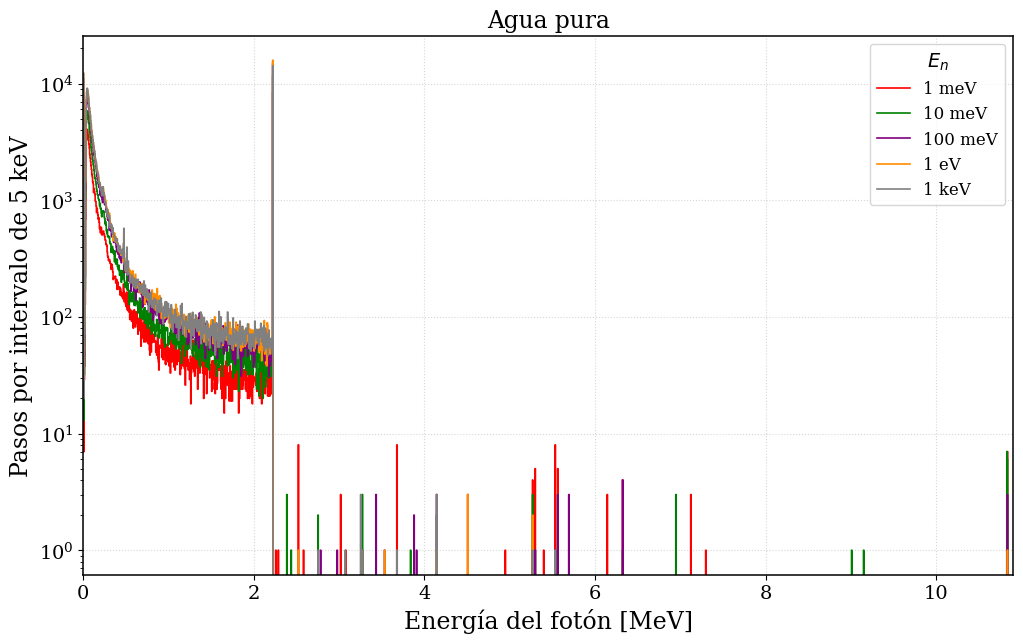

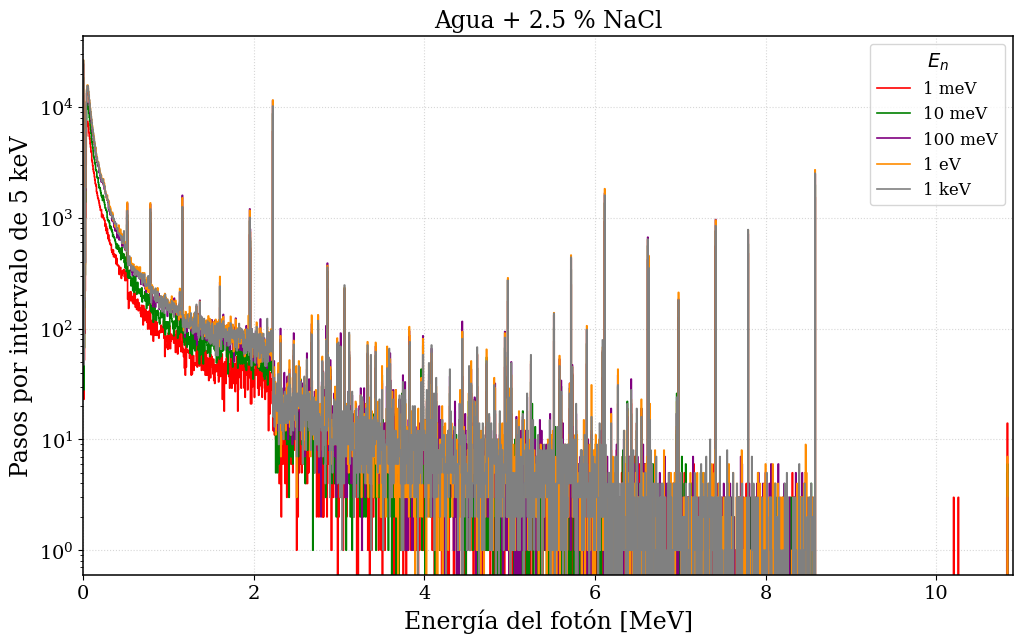

In [5]:
for m, nombre in [("Agua-pura", "fig_4_33_espectro_tanque_agua_pura"), ("Agua+2.5NaCl", "fig_4_34_espectro_tanque_2.5NaCl")]:
    fig, ax = plt.subplots(figsize=(12, 7))
    for e in E5:
        h = R[(e, m)]["histogramas"]["filas_tanque"]
        ax.step(centros(h), h["conteos"], where="mid", color=COLOR_E[e], lw=1.2, label=ROTULO[e])
    ax.set_yscale("log")
    ax.set_xlim(0, 10.9)
    ax.set_xlabel("Energía del fotón [MeV]")
    ax.set_ylabel("Pasos por intervalo de 5 keV")
    ax.set_title(NOMBRE[m])
    ax.legend(title=r"$E_n$")
    ax.grid(True, ls=":", alpha=0.5)
    guardar(fig, nombre)

## Fig. 4.36 y tabla de FWHM: espectro tras la dispersión Compton

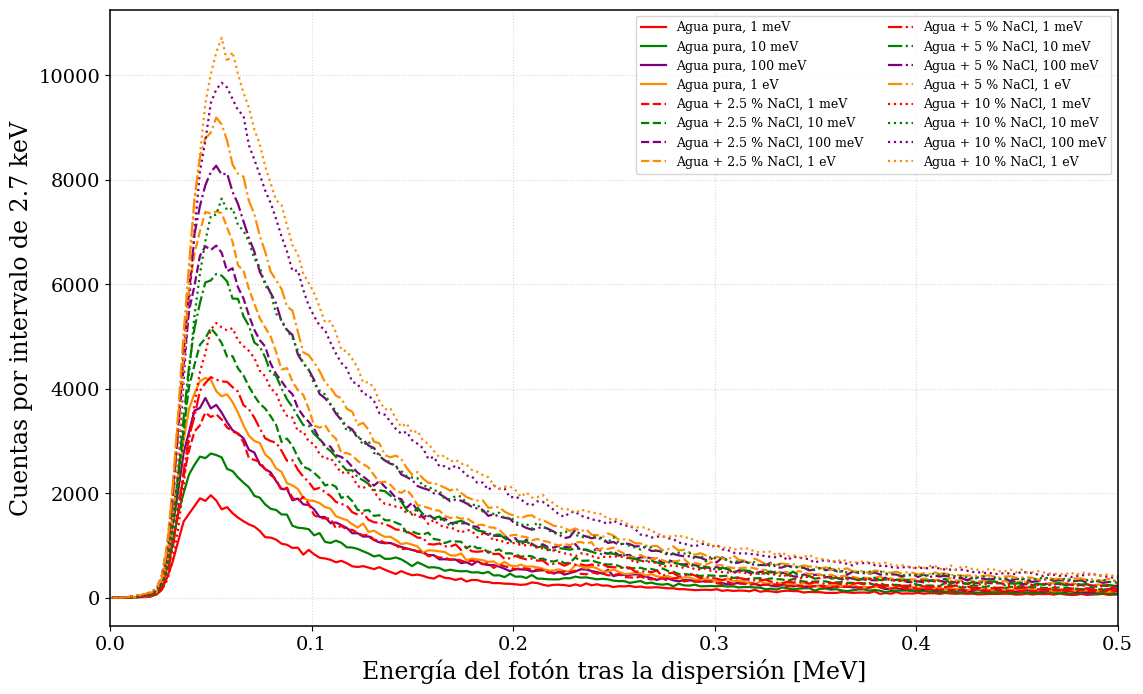

Medio                     E_n    FWHM   E_max   C_max
Agua pura               1 meV   0.054   0.050    1962
Agua pura              10 meV   0.054   0.050    2760
Agua pura             100 meV   0.054   0.047    3825
Agua pura                1 eV   0.057   0.047    4208
Agua + 2.5 % NaCl       1 meV   0.062   0.047    3548
Agua + 2.5 % NaCl      10 meV   0.057   0.050    5163
Agua + 2.5 % NaCl     100 meV   0.059   0.053    6743
Agua + 2.5 % NaCl        1 eV   0.059   0.053    7396
Agua + 5 % NaCl         1 meV   0.062   0.050    4224
Agua + 5 % NaCl        10 meV   0.065   0.053    6200
Agua + 5 % NaCl       100 meV   0.065   0.053    8272
Agua + 5 % NaCl          1 eV   0.062   0.053    9194
Agua + 10 % NaCl        1 meV   0.070   0.053    5261
Agua + 10 % NaCl       10 meV   0.068   0.055    7644
Agua + 10 % NaCl      100 meV   0.068   0.055    9861
Agua + 10 % NaCl         1 eV   0.065   0.055   10723


In [6]:
filas = []
fig, ax = plt.subplots(figsize=(13, 8))
for m in MEDIOS:
    for e in E5[:4]:
        h = R[(e, m)]["histogramas_tesis"]["compt_estricto_2.7MeV_1000"]
        c, x = np.array(h["conteos"]), centros(h)
        ax.plot(x, c, ESTILO[m], color=COLOR_E[e], lw=1.6, label=f"{NOMBRE[m]}, {ROTULO[e]}")
        i = int(np.argmax(c))
        sel = np.where(c >= c[i] / 2)[0]
        filas.append((NOMBRE[m], ROTULO[e], x[sel[-1]] - x[sel[0]], x[i], c[i]))
ax.set_xlim(0, 0.5)
ax.set_xlabel("Energía del fotón tras la dispersión [MeV]")
ax.set_ylabel("Cuentas por intervalo de 2.7 keV")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, ls=":", alpha=0.5)
guardar(fig, "fig_4_36_espectro_compton")
print(f"{'Medio':20s} {'E_n':>8s} {'FWHM':>7s} {'E_max':>7s} {'C_max':>7s}")
for r in filas:
    print(f"{r[0]:20s} {r[1]:>8s} {r[2]:7.3f} {r[3]:7.3f} {r[4]:7d}")

## Fig. 4.39: espectro de los fotones dispersados por Rayleigh

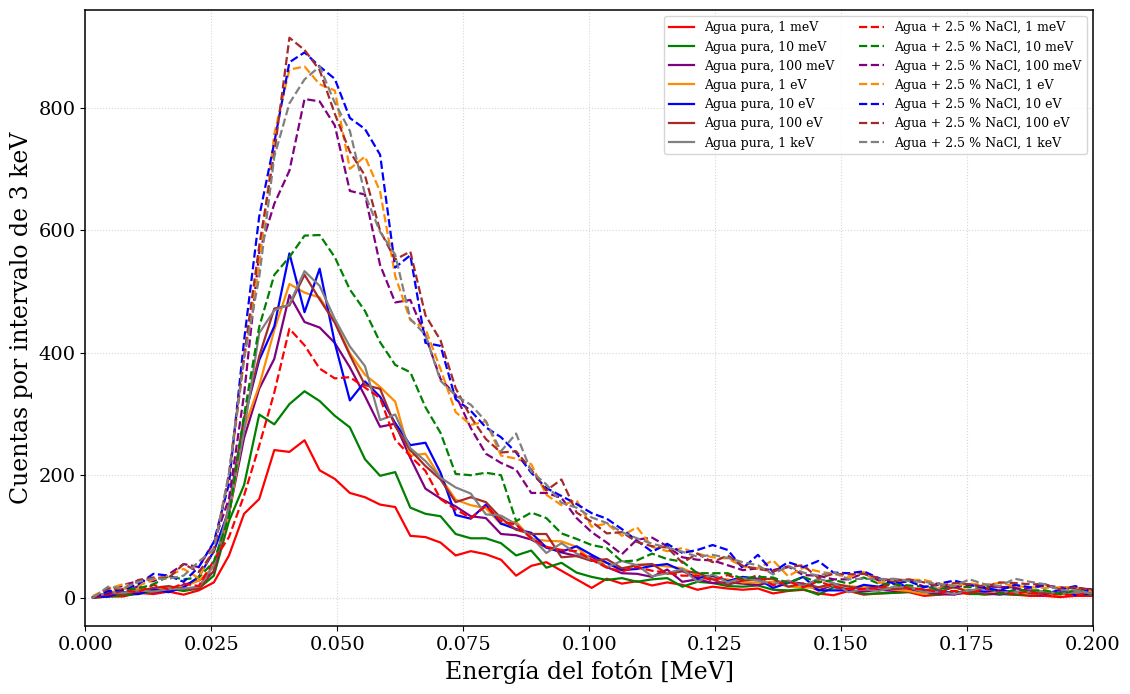

In [7]:
fig, ax = plt.subplots(figsize=(13, 8))
for m in ["Agua-pura", "Agua+2.5NaCl"]:
    for e in E7:
        h = R[(e, m)]["histogramas_tesis"]["Rayl_tanque_3keV"]
        ax.plot(centros(h), h["conteos"], ESTILO[m], color=COLOR_E[e], lw=1.6, label=f"{NOMBRE[m]}, {ROTULO[e]}")
ax.set_xlim(0, 0.2)
ax.set_xlabel("Energía del fotón [MeV]")
ax.set_ylabel("Cuentas por intervalo de 3 keV")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, ls=":", alpha=0.5)
guardar(fig, "fig_4_39_espectro_rayleigh")

## Figs. 4.41 y 4.42: energía de los fotones antes de la fotoabsorción

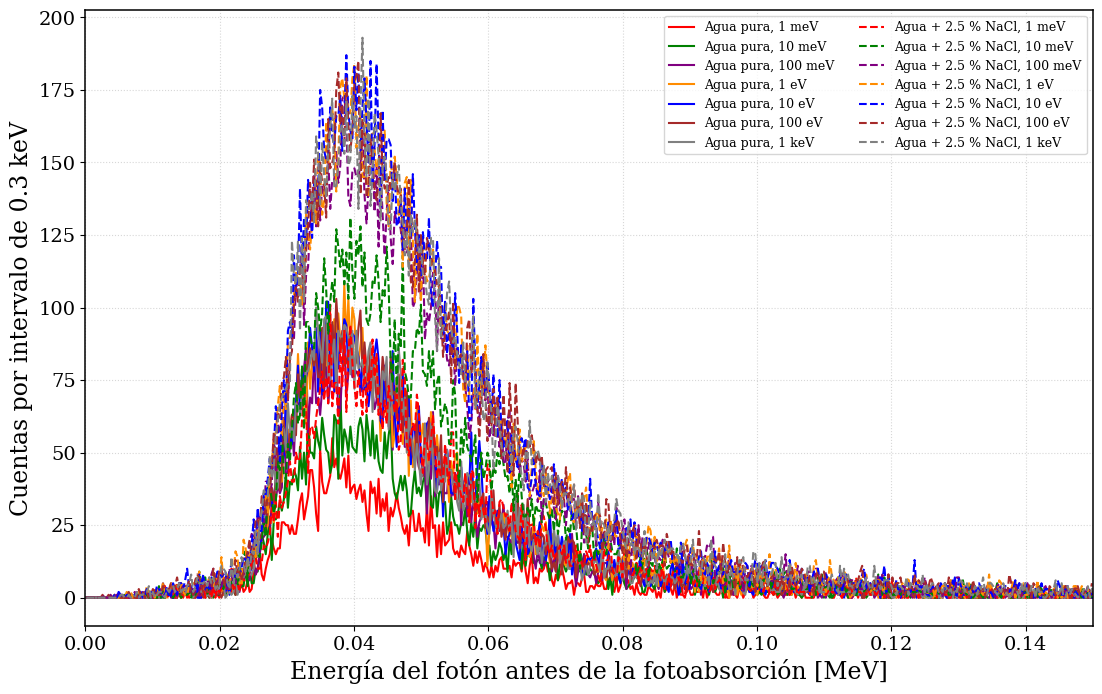

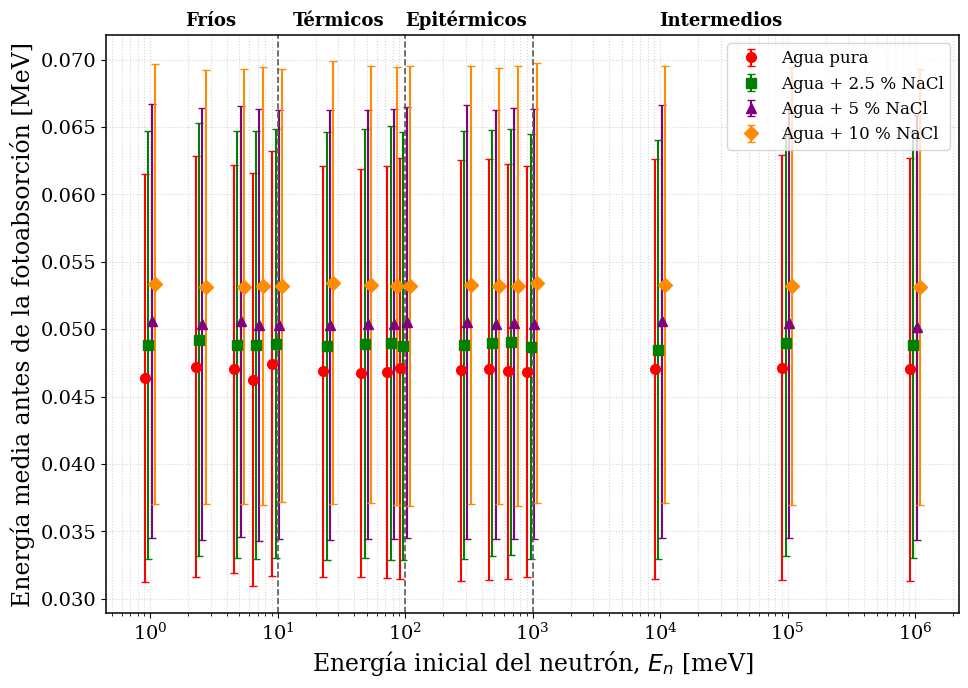

In [8]:
fig, ax = plt.subplots(figsize=(13, 8))
for m in ["Agua-pura", "Agua+2.5NaCl"]:
    for e in E7:
        h = R[(e, m)]["histogramas_tesis"]["phot_previa_compt_0.15MeV_500"]
        ax.plot(centros(h), h["conteos"], ESTILO[m], color=COLOR_E[e], lw=1.5, label=f"{NOMBRE[m]}, {ROTULO[e]}")
ax.set_xlim(0, 0.15)
ax.set_xlabel("Energía del fotón antes de la fotoabsorción [MeV]")
ax.set_ylabel("Cuentas por intervalo de 0.3 keV")
ax.legend(ncol=2, fontsize=9)
ax.grid(True, ls=":", alpha=0.5)
guardar(fig, "fig_4_41_espectro_fotoelectrico")

fig, ax = plt.subplots(figsize=(11, 7.5))
for k, m in enumerate(MEDIOS):
    t = [R[(e, m)]["tesis_fotoabsorcion_previa_compt"]["0.01-0.1MeV"] for e in ENERGIAS]
    ax.errorbar(VALOR_MEV * (1 + 0.06 * (k - 1.5)), [v["media"] for v in t], yerr=[v["std"] for v in t],
                fmt=MARCA[m], color=COLOR[m], capsize=3, ms=7, label=NOMBRE[m])
eje_energia(ax)
ax.set_ylabel("Energía media antes de la fotoabsorción [MeV]")
regiones(ax, 1.01)
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.5)
guardar(fig, "fig_4_42_energia_media_fotoelectrico")

## Figuras nuevas

### Espectro exacto de emisión y energía de las cascadas de captura (1–10 meV)

`gamma-primario-*.txt` guarda la energía exacta de cada fotón de captura y la posición de la captura. Los fotones de
una misma captura comparten la posición: cada grupo es una cascada. La suma de sus energías debería ser el valor $Q$
de la reacción (2.2246 MeV en el $^1$H y 8.5794 MeV en el $^{35}$Cl).

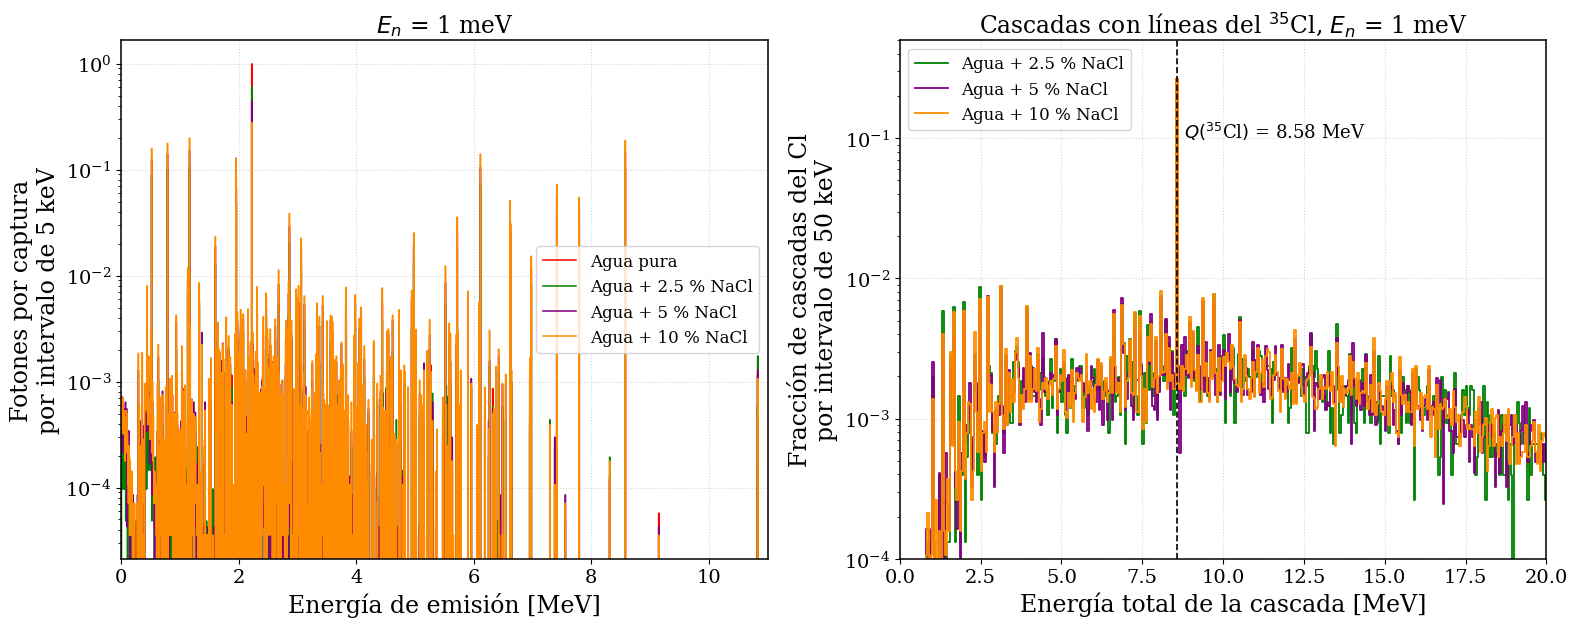

    E_n medio          capturas      H     Cl E_Cl [MeV] conserva Q
  1 meV Agua-pura         17418  17321      0        nan        nan
  1 meV Agua+2.5NaCl      20642  12448   7561     10.137      0.266
  1 meV Agua+5NaCl        23437  10293  12224     10.252      0.265
  1 meV Agua+10NaCl       28107   7783  18939     10.291      0.265
2.5 meV Agua-pura         19899  19801      0        nan        nan
2.5 meV Agua+2.5NaCl      23370  14232   8479     10.222      0.268
2.5 meV Agua+5NaCl        26576  11680  13883     10.207      0.265
2.5 meV Agua+10NaCl       32287   9192  21532     10.245      0.262
  5 meV Agua-pura         22229  22140      0        nan        nan
  5 meV Agua+2.5NaCl      26464  16418   9350     10.224      0.270
  5 meV Agua+5NaCl        29715  13507  15123     10.220      0.271
  5 meV Agua+10NaCl       35625  10398  23546     10.235      0.263
  7 meV Agua-pura         23532  23463      0        nan        nan
  7 meV Agua+2.5NaCl      27873  17165   9962   

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6.5))
for m in MEDIOS:
    h = R[("1meV", m)]["cascadas_captura"]["espectro_emision"]
    axs[0].step(centros(h), np.array(h["conteos"]) / CAP[("1meV", m)], where="mid", color=COLOR[m], lw=1.1,
                label=NOMBRE[m])
axs[0].set_yscale("log")
axs[0].set_xlim(0, 11)
axs[0].set_xlabel("Energía de emisión [MeV]")
axs[0].set_ylabel("Fotones por captura\npor intervalo de 5 keV")
axs[0].set_title(r"$E_n$ = 1 meV")
axs[0].legend()
for m in MEDIOS[1:]:
    t = R[("1meV", m)]["cascadas_captura"]["por_tipo"]["Cl"]["hist_energia_cascada"]
    axs[1].step(centros(t), np.array(t["conteos"]) / t["n"], where="mid", color=COLOR[m], lw=1.3, label=NOMBRE[m])
axs[1].axvline(8.5794, color="k", ls="--", lw=1.2)
axs[1].text(8.8, 0.1, r"$Q(^{35}$Cl$)$ = 8.58 MeV", fontsize=13)
axs[1].set_yscale("log")
axs[1].set_ylim(1e-4, 0.5)
axs[1].set_xlim(0, 20)
axs[1].set_xlabel("Energía total de la cascada [MeV]")
axs[1].set_ylabel("Fracción de cascadas del Cl\npor intervalo de 50 keV")
axs[1].set_title(r"Cascadas con líneas del $^{35}$Cl, $E_n$ = 1 meV")
axs[1].legend()
for ax in axs:
    ax.grid(True, ls=":", alpha=0.5)
fig.tight_layout()
guardar(fig, "fig_nueva_emision_y_cascadas")

print(f"{'E_n':>7s} {'medio':14s} {'capturas':>8s} {'H':>6s} {'Cl':>6s} {'E_Cl [MeV]':>10s} {'conserva Q':>10s}")
for e in ["1meV", "2.5meV", "5meV", "7meV", "10meV"]:
    for m in MEDIOS:
        c = R[(e, m)]["cascadas_captura"]
        cl = c["por_tipo"].get("Cl")
        print(f"{ROTULO[e]:>7s} {m:14s} {c['capturas']:8d} {c['por_tipo']['H']['capturas']:6d} "
              f"{cl['capturas'] if cl else 0:6d} {cl['energia_media_cascada_MeV'] if cl else float('nan'):10.3f} "
              f"{cl['fraccion_conserva_Q'] if cl else float('nan'):10.3f}")

### Destino de los fotones y rendimientos por captura

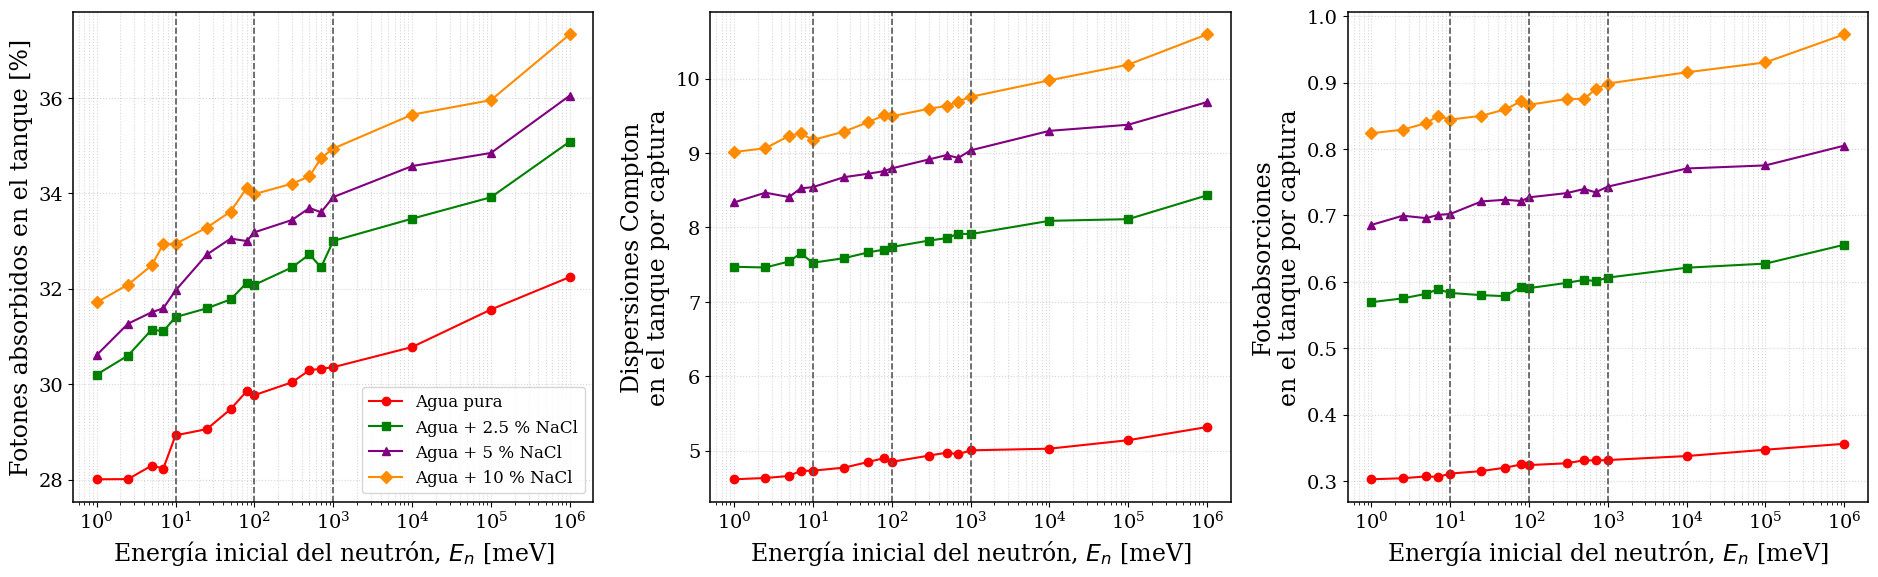

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(19, 6))
for m in MEDIOS:
    abs_f, por_cap_c, por_cap_p = [], [], []
    for e in ENERGIAS:
        r = R[(e, m)]
        d = {k: r["destino"]["neutron"].get(k, 0) + r["destino"]["secundarias"].get(k, 0)
             for k in ("phot_tanque", "conv_tanque", "escapa")}
        abs_f.append(100 * (d["phot_tanque"] + d["conv_tanque"]) / r["trazas"]["total"])
        por_cap_c.append(r["procesos"]["compt"]["tanque"] / CAP[(e, m)])
        por_cap_p.append(r["procesos"]["phot"]["tanque"] / CAP[(e, m)])
    axs[0].plot(VALOR_MEV, abs_f, MARCA[m] + "-", color=COLOR[m], label=NOMBRE[m])
    axs[1].plot(VALOR_MEV, por_cap_c, MARCA[m] + "-", color=COLOR[m], label=NOMBRE[m])
    axs[2].plot(VALOR_MEV, por_cap_p, MARCA[m] + "-", color=COLOR[m], label=NOMBRE[m])
axs[0].set_ylabel("Fotones absorbidos en el tanque [%]")
axs[1].set_ylabel("Dispersiones Compton\nen el tanque por captura")
axs[2].set_ylabel("Fotoabsorciones\nen el tanque por captura")
for ax in axs:
    eje_energia(ax)
    regiones(ax)
    ax.grid(True, which="both", ls=":", alpha=0.5)
axs[0].legend()
fig.tight_layout()
guardar(fig, "fig_nueva_destino_y_rendimiento")

## Verificación frente a la tesis

In [11]:
with open(RES / "verificacion_tesis_gamma.tsv") as f:
    V = list(csv.DictReader(f, delimiter="\t"))
n = {k: sum(1 for v in V if v["estado"] == k) for k in ("igual", "difiere", "sin valor en la tesis")}
print(f"{n['igual']} cifras iguales, {n['difiere']} distintas, {n['sin valor en la tesis']} sin valor en la tesis")
for v in V:
    if v["estado"] == "difiere":
        print(f"  {v['magnitud']:20s} {v['energia']:>11s} {v['medio']:13s} tesis {v['tesis']:>9s}  reproducido {v['reproducido']}")

239 cifras iguales, 13 distintas, 48 sin valor en la tesis
  N_Int(Com)                  1meV Agua+2.5NaCl  tesis    154210  reproducido 154212
  N_Total-int               100meV Agua+5NaCl    tesis    683187  reproducido 636187
  N_Int(Com)                100meV Agua+5NaCl    tesis    372938  reproducido 372939
  N(gamma_Cap)             1000meV Agua-pura     tesis     40640  reproducido 40064
  N_Int(Ext)            1000000meV Agua+10NaCl   tesis    140195  reproducido 140659
  Cmax_Compton               10meV Agua+2.5NaCl  tesis      5153  reproducido 5163
  Cmax_Compton             1000meV Agua+2.5NaCl  tesis      7395  reproducido 7396
  Cmax_Compton              100meV Agua+5NaCl    tesis      8271  reproducido 8272
  phot_media_MeV            100meV Agua+5NaCl    tesis    0.0507  reproducido 0.0505
  phot_sigma_MeV            100meV Agua+5NaCl    tesis    0.0158  reproducido 0.016
  Cmax_Compton                1meV Agua+10NaCl   tesis      5262  reproducido 5261
  phot_media_MeV